# Tarea 2. Regresión supervisada

En este notebook se desarrolla la segunda tarea del proyecto: construir modelos de regresión para predecir la calificación media obtenida por el estudiante en el segundo semestre (`nota_media_2sem`).

## 1. Importación de librerías

Se importan las librerías necesarias para cargar y manipular los datos, construir pipelines de preprocesado, entrenar distintos modelos de regresión y evaluar su rendimiento mediante métricas adecuadas.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)


## 2. Carga del conjunto de datos

Se carga el dataset y se muestran sus dimensiones para comprobar el número de observaciones y variables disponibles.

In [11]:
df = pd.read_csv("rendimiento_estudiantes.csv", sep=";")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (4424, 37)


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


## 3. Definición de la variable objetivo

La variable que se quiere predecir es `nota_media_2sem`, que representa la calificación media obtenida por el estudiante en el segundo semestre.

In [12]:
target = "nota_media_2sem"
y = df[target]

## 4. Selecciones de variables comparadas

Para estudiar el impacto del *data leakage* y la capacidad predictiva real de los datos, se comparan tres configuraciones:

1. **Con todas las variables:** se eliminan únicamente la variable que se busca predecir y la variable `objetivo` de clasificación. Esta configuración puede contener información del segundo semestre, por lo que no es metodológicamente válida, pero sirve como referencia para detectar leakage.
2. **Sin variables del segundo semestre:** se eliminan todas las variables que contienen información del segundo semestre. Esta es la configuración más realista para anticipar la nota del segundo semestre usando información previa.
3. **Sin variables de ningún semestre:** se eliminan variables académicas del primer y segundo semestre. Esta configuración permite medir cuánto poder predictivo tienen únicamente las variables de perfil, contexto y entrada del estudiante.

In [13]:
columnas_excluir_2sem = [col for col in df.columns if "2sem" in col] + ["objetivo"]
columnas_excluir_1sem = [col for col in df.columns if "1sem" in col] + ["objetivo"]
columnas_excluir_sem = list(set(columnas_excluir_2sem + columnas_excluir_1sem))

# Configuración A: con todas las variables salvo target y objetivo de clasificación
X_con_todo = df.drop(columns=["nota_media_2sem", "objetivo"])

# Configuración B: sin variables del segundo semestre
X_sin_2sem = df.drop(columns=columnas_excluir_2sem)

# Configuración C: sin variables de ningún semestre
X_sin_sem = df.drop(columns=columnas_excluir_sem)

print("Variables con todo:", X_con_todo.shape[1])
print("Variables sin 2º semestre:", X_sin_2sem.shape[1])
print("Variables sin ningún semestre:", X_sin_sem.shape[1])

Variables con todo: 35
Variables sin 2º semestre: 30
Variables sin ningún semestre: 24


## 5. Modelos de regresión evaluados

Se comparan modelos con distintos niveles de complejidad:

- `DummyRegressor`: modelo base que predice siempre la media del target.
- `LinearRegression`: modelo lineal sencillo e interpretable.
- `RandomForestRegressor`: modelo no lineal basado en árboles.
- `GradientBoostingRegressor`: modelo ensamblado que suele capturar relaciones complejas de forma eficaz.


In [14]:
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

## 6. Función de evaluación

Se define una función para evaluar cada selección de variables de forma homogénea.

Dentro de la función se realizan los siguientes pasos:

1. Separar variables numéricas y categóricas.
2. Dividir los datos en entrenamiento y test.
3. Crear el preprocesado: imputación, escalado y codificación one-hot.
4. Evaluar cada modelo con validación cruzada de 5 particiones.
5. Seleccionar el mejor modelo según el menor RMSE medio en validación cruzada.
6. Entrenar el modelo final y evaluarlo sobre el conjunto de test.

Las métricas utilizadas son:

- **MAE:** error absoluto medio.
- **RMSE:** raíz del error cuadrático medio, penaliza más los errores grandes.
- **R²:** proporción de varianza explicada por el modelo.

In [27]:
def evaluar_seleccion(X, y, nombre_seleccion):
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    transformar_numericas = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformar_categoricas = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", transformar_numericas, num_cols),
        ("cat", transformar_categoricas, cat_cols)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        mae_cv = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )

        rmse_cv = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

        r2_cv = cross_val_score(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring="r2",
            n_jobs=-1
        )

        results.append({
            "seleccion_variables": nombre_seleccion,
            "modelo": name,
            "num_variables": X.shape[1],
            "MAE_cv_mean": -mae_cv.mean(),
            "MAE_cv_std": mae_cv.std(),
            "RMSE_cv_mean": -rmse_cv.mean(),
            "RMSE_cv_std": rmse_cv.std(),
            "R2_cv_mean": r2_cv.mean(),
            "R2_cv_std": r2_cv.std()
        })

    results_df = pd.DataFrame(results).sort_values(by="RMSE_cv_mean", ascending=True)

    best_model_name = results_df.iloc[0]["modelo"]
    best_model = models[best_model_name]

    print(f"\nMejor modelo para {nombre_seleccion}: {best_model_name}")

    final_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ])

    final_pipeline.fit(X_train, y_train)
    y_pred = final_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Métricas en test - {nombre_seleccion}")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2:    {r2:.4f}")

    return {
        "seleccion_variables": nombre_seleccion,
        "mejor_modelo": best_model_name,
        "num_variables": X.shape[1],
        "MAE_test": mae,
        "RMSE_test": rmse,
        "R2_test": r2,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred
    }

## 7. Evaluación de las tres configuraciones

Se aplica la función anterior a las tres selecciones de variables. Esto permite comparar directamente cómo cambia el rendimiento cuando se incluye o se elimina información.

In [26]:
res_con_todo = evaluar_seleccion(X_con_todo, y, "Con todas las variables")
res_sin_2sem = evaluar_seleccion(X_sin_2sem, y, "Sin variables de 2º semestre")
res_sin_sem = evaluar_seleccion(X_sin_sem, y, "Sin variables de cualquier semestre")

Mejor modelo para Con todas las variables: GradientBoostingRegressor
Métricas en test - Con todas las variables
MAE:   0.6181
RMSE:  0.8935
R2:    0.9705
Mejor modelo para Sin variables de 2º semestre: RandomForestRegressor
Métricas en test - Sin variables de 2º semestre
MAE:   1.3901
RMSE:  2.6957
R2:    0.7316
Mejor modelo para Sin variables de cualquier semestre: RandomForestRegressor
Métricas en test - Sin variables de cualquier semestre
MAE:   3.0814
RMSE:  4.4563
R2:    0.2665


## 8. Resumen comparativo final

Se construye una tabla resumen con el mejor modelo de cada selección y sus métricas en test. Esta tabla es útil para interpretar el efecto de las distintas configuraciones de variables.

En general, si la configuración con todas las variables obtiene métricas extremadamente superiores, puede ser una señal clara de *data leakage*.

In [17]:
resumen = pd.DataFrame([
    {
        "seleccion_variables": res_con_todo["seleccion_variables"],
        "mejor_modelo": res_con_todo["mejor_modelo"],
        "num_variables": res_con_todo["num_variables"],
        "MAE_test": res_con_todo["MAE_test"],
        "RMSE_test": res_con_todo["RMSE_test"],
        "R2_test": res_con_todo["R2_test"]
    },
    {
        "seleccion_variables": res_sin_2sem["seleccion_variables"],
        "mejor_modelo": res_sin_2sem["mejor_modelo"],
        "num_variables": res_sin_2sem["num_variables"],
        "MAE_test": res_sin_2sem["MAE_test"],
        "RMSE_test": res_sin_2sem["RMSE_test"],
        "R2_test": res_sin_2sem["R2_test"]
    },
    {
        "seleccion_variables": res_sin_sem["seleccion_variables"],
        "mejor_modelo": res_sin_sem["mejor_modelo"],
        "num_variables": res_sin_sem["num_variables"],
        "MAE_test": res_sin_sem["MAE_test"],
        "RMSE_test": res_sin_sem["RMSE_test"],
        "R2_test": res_sin_sem["R2_test"]
    }
])

print(" Resumen final de las tres selecciones:")
print(resumen.round(4))

resumen.round(4)

 Resumen final de las tres selecciones:
                   seleccion_variables               mejor_modelo  \
0              Con todas las variables  GradientBoostingRegressor   
1         Sin variables de 2º semestre      RandomForestRegressor   
2  Sin variables de cualquier semestre      RandomForestRegressor   

   num_variables  MAE_test  RMSE_test  R2_test  
0             35    0.6181     0.8935   0.9705  
1             30    1.3901     2.6957   0.7316  
2             24    3.0814     4.4563   0.2665  


,seleccion_variables,mejor_modelo,num_variables,MAE_test,RMSE_test,R2_test
0,Con todas las variables,GradientBoostingRegressor,35,0.6181,0.8935,0.9705
1,Sin variables de 2º semestre,RandomForestRegressor,30,1.3901,2.6957,0.7316
2,Sin variables de cualquier semestre,RandomForestRegressor,24,3.0814,4.4563,0.2665


## 9. Análisis gráfico del modelo sin variables del segundo semestre

La configuración sin variables del segundo semestre es la más relevante desde el punto de vista metodológico, porque evita utilizar información contemporánea al target.

Por ello, se analizan gráficamente sus predicciones mediante:

1. Un gráfico de valores reales frente a valores predichos.
2. Un gráfico de residuos, que permite observar si los errores presentan patrones sistemáticos.

In [18]:
y_test = res_sin_2sem["y_test"]
y_pred = res_sin_2sem["y_pred"]
best_model_name = res_sin_2sem["mejor_modelo"]

### 9.1. Gráfico de valores reales frente a predichos

En este gráfico, cuanto más cerca estén los puntos de la diagonal, mejores serán las predicciones. Desviaciones grandes respecto a la diagonal indican errores de predicción más elevados.

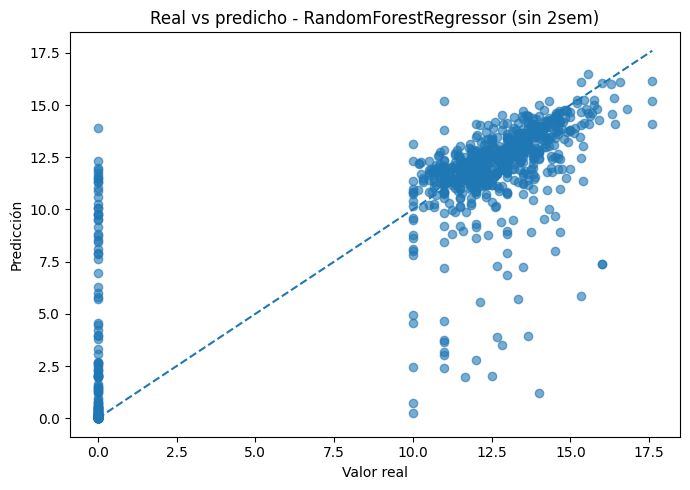

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Real vs predicho - {best_model_name} (sin 2sem)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()

### 9.2. Gráfico de residuos

Los residuos se calculan como la diferencia entre el valor real y la predicción. Un buen modelo debería mostrar residuos distribuidos alrededor de cero, sin patrones claros.

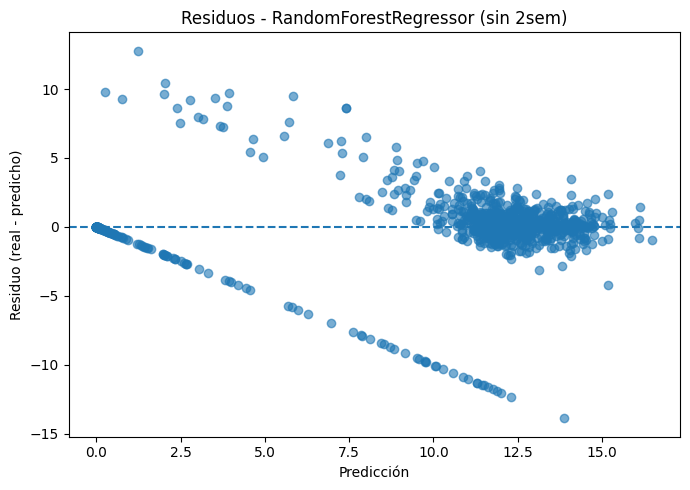

In [20]:
residuos = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo (real - predicho)")
plt.title(f"Residuos - {best_model_name} (sin 2sem)")
plt.tight_layout()
plt.show()

## 10. Interpretación general

La comparación entre las tres configuraciones permite analizar qué información aporta realmente capacidad predictiva:

- Si el modelo con todas las variables obtiene un rendimiento muy superior, probablemente está aprovechando información del segundo semestre relacionada directamente con el target.
- La configuración sin variables del segundo semestre representa el escenario más realista para anticipar el rendimiento futuro.
- La configuración sin variables académicas de ningún semestre permite comprobar cuánto explican por sí solas las variables de perfil, contexto socioeconómico y entrada del estudiante.
